#### Outline

- [Project Setup & Data Ingestion](#Project-Setup-&-Data-Ingestion)
- [Data Understanding & Exploration](#Data-Understanding-&-Exploration)
- [Data Preparation & Feature Engineering](#Data-Preparation-&-Feature-Engineering)    
- [Model Building, Evaluation & Diagnostics](#Model-Building,-Evaluation-&-Diagnostics)
- [Model Deployment & Inference](#Model-Deployment-&-Inference)
- [Reporting & Business Insights](#Reporting-&-Business-Insights)
            

#### Project Setup & Data Ingestion

Project Title

In [ ]:
# Livestock Sales Revenue Prediction Using Machine Learning

## Project Overview

# The Project is aimed at developing a  a machine learning model with Python in livestock sales prediction using old business transaction records.
# We will  explore the factors that influence livestock business my appling machine learning model, which include data inspection and
# preprocessing, cleaning, exploratory data analysis, predictive modelling and feature engineering to build and evaluate 
# accurate revenue prediction models.


## Objectives

# The project objectives are:

# - Livestock business prediction by using old transaction data.
# - Identify that factors which affect livestock business.
# - Build and evaluate a model which can be used to predict revenues.
# - Provide insights which could be used to support decision that will improve livestock revenue.

## Expected Outcome

# The best model will assist farmers, livestock traders and agricultural stakeholders 
# to forecast livestock revenue and improve business strategy .

Import Libraries

In [1]:

# Import Required Libraries


# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score

# Model Evaluation
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Model Saving
import joblib

# Plot Settings
plt.style.use("ggplot")



Load Dataset

In [2]:

# Load Dataset

sales = pd.read_csv(r"C:\Users\Emeka\Desktop\unv\fact_Livestock_Sales.csv")
farmers = pd.read_csv(r"C:\Users\Emeka\Desktop\unv\dim_Farmers.csv")
geo = pd.read_csv(r"C:\Users\Emeka\Desktop\unv\dim_Geography_Mapping.csv")




In [3]:
# Merge Tables

# Tables are merged based on the common columns found within Tables
# "Farmer_ID" is common in "sales" and "farmers" Tables
# "Geographic_Zone" is common in "geo" and "farmers Tables"

df = sales.merge(
    farmers,
    on="Farmer_ID",
    how="left"
)

df = df.merge(
    geo,
    on="Geographic_Zone",
    how="left"
)

print(df.shape)
df.head()


(1500, 12)


,Transaction_ID,Farmer_ID,Livestock_Type,Number_Sold,Distance_to_Market_km,Total_Value_Naira,Date,Gender,Age,Geographic_Zone,Average_Annual_Rainfall_mm,Vulnerability_Index_Score
0,T-1000,F-201,Goat,4,2.2,158909,2026-03-03,Male,64,North-East,380,0.85
1,T-1001,F-179,Cattle,6,15.3,2691434,2026-05-23,Male,44,South-South,1800,0.32
2,T-1002,F-158,Cattle,2,27.8,955505,2026-01-14,Female,58,South-East,1400,0.41
3,T-1003,F-216,Goat,3,19.6,114303,2026-04-26,Male,24,South-East,1400,0.41
4,T-1004,F-202,Poultry,20,24.0,57117,2026-04-18,Female,22,South-South,1800,0.32


#### Data Understanding & Exploration

4. Understanding Data

Data Information

In [4]:
# Data Information

print("Dataset Information")

df.info()

Dataset Information
<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Transaction_ID              1500 non-null   str    
 1   Farmer_ID                   1500 non-null   str    
 2   Livestock_Type              1500 non-null   str    
 3   Number_Sold                 1500 non-null   int64  
 4   Distance_to_Market_km       1494 non-null   float64
 5   Total_Value_Naira           1500 non-null   int64  
 6   Date                        1500 non-null   str    
 7   Gender                      1500 non-null   str    
 8   Age                         1500 non-null   int64  
 9   Geographic_Zone             1500 non-null   str    
 10  Average_Annual_Rainfall_mm  1500 non-null   int64  
 11  Vulnerability_Index_Score   1500 non-null   float64
dtypes: float64(2), int64(4), str(6)
memory usage: 140.8 KB


Statistical Summary

In [5]:



display(df.describe(include='all'))

,Transaction_ID,Farmer_ID,Livestock_Type,Number_Sold,Distance_to_Market_km,Total_Value_Naira,Date,Gender,Age,Geographic_Zone,Average_Annual_Rainfall_mm,Vulnerability_Index_Score
count,1500,1500,1500,1500.00000,1494.00000,1.500000e+03,1500,1500,1500.000000,1500,1500.000000,1500.000000
unique,1500,300,3,NaN,NaN,NaN,180,2,NaN,4,NaN,NaN
top,T-1000,F-201,Poultry,NaN,NaN,NaN,2026-04-29,Male,NaN,North-West,NaN,NaN
freq,1,12,758,NaN,NaN,NaN,19,812,NaN,454,NaN,NaN
mean,NaN,NaN,NaN,25.08600,18.70830,3.468083e+05,NaN,NaN,55.802000,NaN,942.866667,0.610667
std,NaN,NaN,NaN,23.15101,10.99634,8.848314e+05,NaN,NaN,104.632991,NaN,586.678143,0.221783
min,NaN,NaN,NaN,1.00000,0.50000,3.057400e+04,NaN,NaN,18.000000,NaN,380.000000,0.320000
25%,NaN,NaN,NaN,4.00000,10.20000,1.149608e+05,NaN,NaN,37.000000,NaN,450.000000,0.410000
50%,NaN,NaN,NaN,18.00000,18.00000,1.529900e+05,NaN,NaN,45.000000,NaN,450.000000,0.780000
75%,NaN,NaN,NaN,43.00000,26.47500,2.155115e+05,NaN,NaN,53.000000,NaN,1400.000000,0.780000


Check Missing Values

In [6]:

print("Missing Values")


missing = df.isnull().sum()

missing = pd.DataFrame({
    "Missing Values": missing,
    "Percentage": round((missing/len(df))*100,2)
})

display(missing.sort_values(
    by="Missing Values",
    ascending=False
))

Missing Values


,Missing Values,Percentage
Distance_to_Market_km,6,0.4
Transaction_ID,0,0.0
Livestock_Type,0,0.0
Farmer_ID,0,0.0
Number_Sold,0,0.0
Total_Value_Naira,0,0.0
Date,0,0.0
Gender,0,0.0
Age,0,0.0
Geographic_Zone,0,0.0


Duplicate Records

In [7]:
duplicates = df.duplicated().sum()

print(f"Duplicate Records : {duplicates}")

Duplicate Records : 0


4.5 Data Type

In [8]:
print(df.dtypes)

Transaction_ID                    str
Farmer_ID                         str
Livestock_Type                    str
Number_Sold                     int64
Distance_to_Market_km         float64
Total_Value_Naira               int64
Date                              str
Gender                            str
Age                             int64
Geographic_Zone                   str
Average_Annual_Rainfall_mm      int64
Vulnerability_Index_Score     float64
dtype: object


4.6 Unique Values

In [10]:
for col in df.columns:



    print(col)

    print(df[col].nunique())

Transaction_ID
1500
Farmer_ID
300
Livestock_Type
3
Number_Sold
87
Distance_to_Market_km
414
Total_Value_Naira
1494
Date
180
Gender
2
Age
51
Geographic_Zone
4
Average_Annual_Rainfall_mm
4
Vulnerability_Index_Score
4


In [ ]:
# Observations

# From the above result, the dataset contains 1,500 records with 6 missing Distance values. 
# Though with the percentage of missing value, it can be ignored
# The Number Sold is positively skewed(right-skewed) with outliers.
# Number_sold => Mean = 25.09, Median = 18, Min = 1, Max = 113, Sd = 23.15.(the measure of how spread out the values are, is from the mean value)  
# Distance to Market contains some large values up to 60 Km
# Total value in naira is also heavily right-skewed with extreme revenue outliers
# The age has outlier which could be an error. The figure is far from being real
# The Mean values are larger than Medians, confirming right-skew.
# For instance the Distance  mean(18.71) and the median(18.00).
# The 6 missing Distance values will be filled with median(18 km), this is a right choice and it will not distort the data
# In summary the dataset is positively skewed(right-skewed), where the means are higher 
# than the medians and there are outliers
# Date is in string and need to be converted so that we are not be prevented from performing chronological sorting,
# There are no duplicates

5 Data Cleaning

5.1 handle Missing Values

In [11]:
# Fill the missing Disatnce values with the median value(18km)
df['Distance_to_Market_km'] = df['Distance_to_Market_km'].fillna(
    df['Distance_to_Market_km'].median()
)

In [13]:
# Since the age is an error, we have to replace the age with the Median Age

# Replace 999 with NaN
df['Age'] = df['Age'].replace(999, np.nan)

# Fill missing Age with median
df['Age'] = df['Age'].fillna(df['Age'].median())

5.3 Correct Data Type

In [12]:
# correcting Date type

df["Date"] = pd.to_datetime(
    df["Date"]
)

5.4 Check Missing Values Again

In [13]:
df.isnull().sum()

Transaction_ID                0
Farmer_ID                     0
Livestock_Type                0
Number_Sold                   0
Distance_to_Market_km         0
Total_Value_Naira             0
Date                          0
Gender                        0
Age                           0
Geographic_Zone               0
Average_Annual_Rainfall_mm    0
Vulnerability_Index_Score     0
dtype: int64

5.5 Re-check Dataset Information

In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   Transaction_ID              1500 non-null   str           
 1   Farmer_ID                   1500 non-null   str           
 2   Livestock_Type              1500 non-null   str           
 3   Number_Sold                 1500 non-null   int64         
 4   Distance_to_Market_km       1500 non-null   float64       
 5   Total_Value_Naira           1500 non-null   int64         
 6   Date                        1500 non-null   datetime64[us]
 7   Gender                      1500 non-null   str           
 8   Age                         1500 non-null   int64         
 9   Geographic_Zone             1500 non-null   str           
 10  Average_Annual_Rainfall_mm  1500 non-null   int64         
 11  Vulnerability_Index_Score   1500 non-null   float64       
dtypes: 

In [15]:
# Observation
# The date has been converted
# No more missing values
# The error in Age has been corrected with the Median value

6. Exploratory Data Analysis

6.1 Revenue Distribution

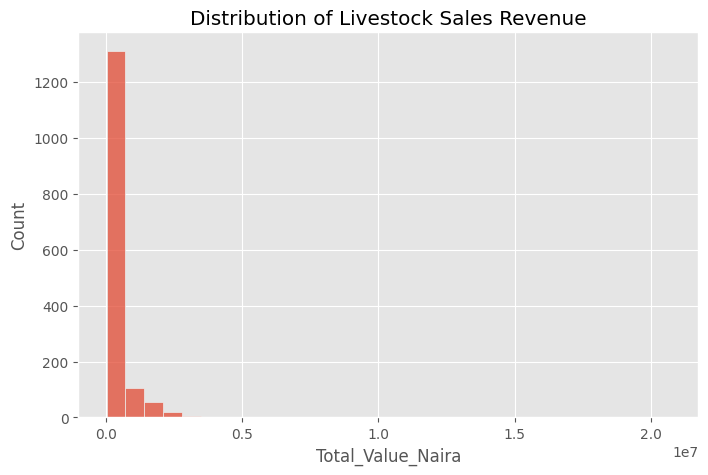

In [15]:
plt.figure(figsize=(8,5))

sns.histplot(df["Total_Value_Naira"], bins=30)

plt.title("Distribution of Livestock Sales Revenue")

plt.show()

In [16]:
# From the information above
# 1. It is heavily Right-Skewed. The majority of livestock sales are concentrated heavily at the very low end
# 2. It has high-value outliers
# Further explanation, some farmers recorded over 1,300 transactions and earned between zero Naira and roughly N500,000.00
# While some farmers with transaction less than 100 transactions are earning more.
# The second bar is assumed to be 110-120 Count with Revenue(between N500,000 to N1,000,000)
# The thrid bar, assumed t be 60-70 Count with Revenue(N1,000,000 to N1,500,000)
# Fourt bar, assumed (20-30) Count with Revenue(N1,500,000 to N2,000,000)

6.2 Revenue By Livestock Type

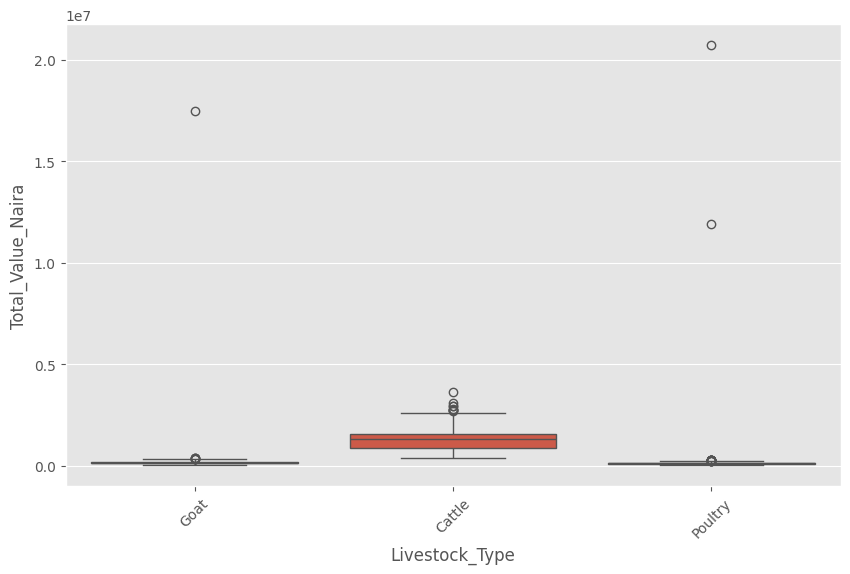

In [16]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x="Livestock_Type",
    y="Total_Value_Naira",
    data=df
)

plt.xticks(rotation=45)

plt.show()

In [ ]:
# Observation
# Goat and Poultry has massive outliers. With Goat 1, and Poultry 2. These two are completely skewed, 
# forcing the rest of the data look completely flat. The Goat and Poultry bring in very low revenue per individual
# The Cattle yields noticeable higher revenue per sale than both Goat and Poultry

# More explanation 
# Cattle
# The box under the cattle is visible when compared with Goat and Poultry.
# Which indicate that  Cattle sales  generate higher revenue per transaction which comes  around ₦1M to ₦2M as the box contains. 
# commands a high market price.
# Goat & Poultry 
# They have  Low Baseline. Their boxes almost collapsed.
# Large number farmers make little or no sales which result to littel total revenues under N500,000 
# While very little of the who a big time farmers who are the extreme outliers earn up to N12 million to N20 Million

6.3 Revenue by Geographic Zone

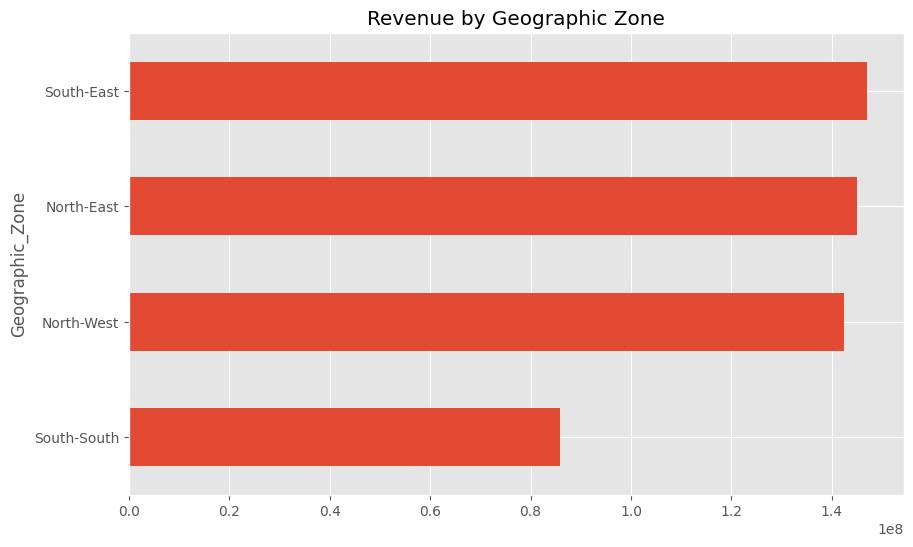

In [17]:
state_revenue = df.groupby("Geographic_Zone")["Total_Value_Naira"].sum()

state_revenue.sort_values().plot(
    kind="barh",
    figsize=(10,6)
)

plt.title("Revenue by Geographic Zone")

plt.show()

6.4 Correlation Heatmap

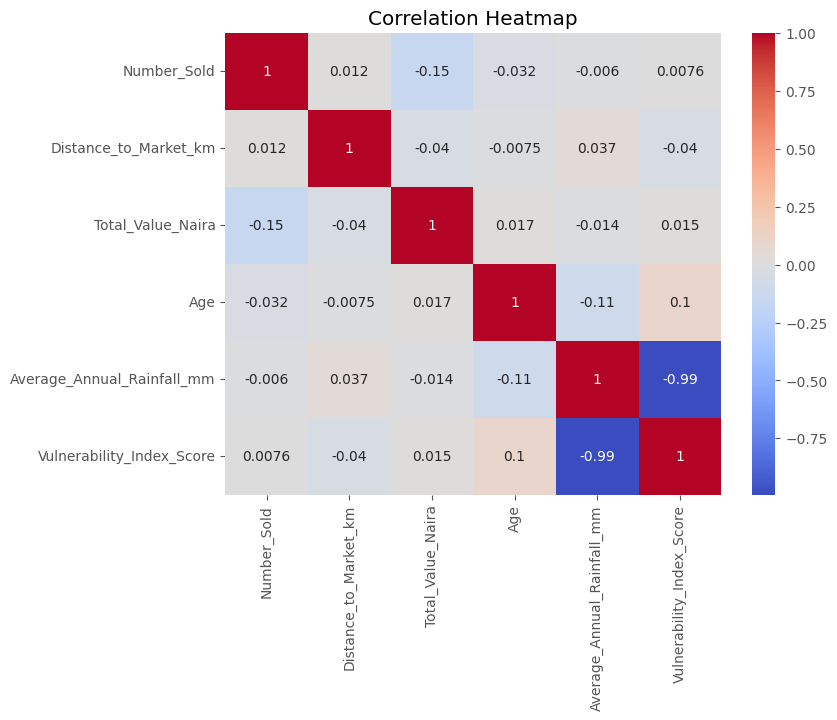

In [19]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

In [ ]:
# Breakdown of the Correlation Heatmap.

# +1.00 (Deep Red): ==> Perfect positive correlation (as one increases, the other increases proportionally).
# 0.00 (Grey/Neutral): ==>  No linear relationship.
# -1.00 (Deep Blue): ==> Perfect negative correlation (as one increases, the other decreases proportionally).

# Average_Annual_Rainfall_mm vs. Vulnerability_Index_Score ==> -0.99(Deep Blue)(Strong negative correlation)
# Which means there is extremely strong nagative relationship between both variables. When the annual rainfall is lower
# the vulnerability index scores is high.

# Number_Sold vs. Total_Value_Naira ==>-0.15(Light Blue)(Weak Negative Correlation)
# Which means slight tendecy for higer total value to mean fewer items sold.

# Distance_to_Market_km, Age, Number_Sold and Total_Value_Naira have no linear relationship with each other or with rainfall.

# The differences in market distance or age is not a predictable variable in this dataset.

# Major variables to check, the relationship between Average_Annual_Rainfall_mm and Vulnerability_Index_Score 

6.5 Business Insights

In [ ]:

# Key Findings from the Exploratory Data Analysis

# Livestock sales revenue is positively associated with the quantity sold.
# Revenue varies across different states and market locations.
# Seasonal patterns suggest periods of increased sales activity.
# Some numerical variables exhibit skewness, supporting the use of a log transformation before model training.

#### Data Preparation & Feature Engineering

7. Feature Engineering

7.1 Create Revenue Capped Variable

In [20]:

# Create Revenue Capped Variable


upper_limit = df["Total_Value_Naira"].quantile(0.99)

df["Revenue_Capped"] = np.where(
    df["Total_Value_Naira"] > upper_limit,
    upper_limit,
    df["Total_Value_Naira"]
)

7.2 Log Transformation

In [21]:
# Log Transformation


df["Log_Revenue"] = np.log1p(df["Revenue_Capped"])

7.3 Extract Date Features

In [22]:
# Date Features


df["Date"] = pd.to_datetime(df["Date"])

df["Year"] = df["Date"].dt.year

df["Month"] = df["Date"].dt.month

df["Quarter"] = df["Date"].dt.quarter

7.4 Create Season Variable

In [23]:
# Create Season Variable


df["Season"] = np.where(
    df["Month"].isin([11,12,1,2,3]),
    "Dry",
    "Rainy"
)



7.5 Verify Newly Created Features

In [24]:
new_features = [
    "Revenue_Capped",
    "Log_Revenue",
    "Year",
    "Month",
    "Quarter",
    "Season"
]

display(df[new_features].head())

,Revenue_Capped,Log_Revenue,Year,Month,Quarter,Season
0,158909.00,11.976093,2026,3,1,Dry
1,2404782.38,14.692970,2026,5,2,Rainy
2,955505.00,13.769996,2026,1,1,Dry
3,114303.00,11.646617,2026,4,2,Rainy
4,57117.00,10.952875,2026,4,2,Rainy


Save The Dataset

In [25]:
df.to_csv(r'C:\Users\Emeka\Desktop\unv\df_unvol.csv', index=False)

8. Encode Categorical Variables

In [26]:
# Machine learning algorithms require numerical input, so categorical variables are encoded using one-hot encoding.

# Encode Categorical Variables


df_encoded = pd.get_dummies(
    df,
    drop_first=True
)

print("Original Dataset Shape :", df.shape)
print("Encoded Dataset Shape  :", df_encoded.shape)

Original Dataset Shape : (1500, 18)
Encoded Dataset Shape  : (1500, 1817)


In [27]:
# There is an error, the columns of 1817 is unbelievable. From 13 to over 1,800.
# Steps to be taken

# Drop identifier columns before encoding
df_model = df.drop(columns=["Transaction_ID", "Farmer_ID"], errors="ignore")

# If Transaction_Date is still present and not yet engineered, drop it for encoding
df_model = df_model.drop(columns=["Date"], errors="ignore")

# Encode only categorical columns
categorical_columns = df_model.select_dtypes(include=["object", "category"]).columns

df_encoded = pd.get_dummies(
    df_model,
    columns=categorical_columns,
    drop_first=True
)

print("Original Dataset Shape :", df.shape)
print("Model Dataset Shape    :", df_model.shape)
print("Encoded Dataset Shape  :", df_encoded.shape)


Original Dataset Shape : (1500, 18)
Model Dataset Shape    : (1500, 15)
Encoded Dataset Shape  : (1500, 18)


In [28]:
# Verify Encoded Dataset

display(df_encoded.head())

,Number_Sold,Distance_to_Market_km,Total_Value_Naira,Age,Average_Annual_Rainfall_mm,Vulnerability_Index_Score,Revenue_Capped,Log_Revenue,Year,Month,Quarter,Livestock_Type_Goat,Livestock_Type_Poultry,Gender_Male,Geographic_Zone_North-West,Geographic_Zone_South-East,Geographic_Zone_South-South,Season_Rainy
0,4,2.2,158909,64,380,0.85,158909.00,11.976093,2026,3,1,True,False,True,False,False,False,False
1,6,15.3,2691434,44,1800,0.32,2404782.38,14.692970,2026,5,2,False,False,True,False,False,True,True
2,2,27.8,955505,58,1400,0.41,955505.00,13.769996,2026,1,1,False,False,False,False,True,False,False
3,3,19.6,114303,24,1400,0.41,114303.00,11.646617,2026,4,2,True,False,True,False,True,False,True
4,20,24.0,57117,22,1800,0.32,57117.00,10.952875,2026,4,2,False,True,False,False,False,True,True


9. Define Features and Target

In [29]:
# The target variable is the log-transformed revenue.

# Define Target Variable and Features


y = df_encoded["Log_Revenue"]

X = df_encoded.drop(columns=[
    "Transaction_ID",
    "Farmer_ID",
    "Transaction_Date",
    "Total_Value_Naira",
    "Revenue_Capped",
    "Log_Revenue",
    "Year"
], errors="ignore")

print("Feature Matrix Shape :", X.shape)
print("Target Variable Shape:", y.shape)

Feature Matrix Shape : (1500, 14)
Target Variable Shape: (1500,)


In [30]:
# Verify Features

display(X.head())

,Number_Sold,Distance_to_Market_km,Age,Average_Annual_Rainfall_mm,Vulnerability_Index_Score,Month,Quarter,Livestock_Type_Goat,Livestock_Type_Poultry,Gender_Male,Geographic_Zone_North-West,Geographic_Zone_South-East,Geographic_Zone_South-South,Season_Rainy
0,4,2.2,64,380,0.85,3,1,True,False,True,False,False,False,False
1,6,15.3,44,1800,0.32,5,2,False,False,True,False,False,True,True
2,2,27.8,58,1400,0.41,1,1,False,False,False,False,True,False,False
3,3,19.6,24,1400,0.41,4,2,True,False,True,False,True,False,True
4,20,24.0,22,1800,0.32,4,2,False,True,False,False,False,True,True


#### Model Building, Evaluation & Diagnostics

10. Train-Test Split

In [31]:
# The dataset is divided into training and testing subsets

# Split Dataset

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Set :", X_train.shape)
print("Testing Set  :", X_test.shape)

Training Set : (1200, 14)
Testing Set  : (300, 14)


In [32]:
print(df.columns.tolist())

['Transaction_ID', 'Farmer_ID', 'Livestock_Type', 'Number_Sold', 'Distance_to_Market_km', 'Total_Value_Naira', 'Date', 'Gender', 'Age', 'Geographic_Zone', 'Average_Annual_Rainfall_mm', 'Vulnerability_Index_Score', 'Revenue_Capped', 'Log_Revenue', 'Year', 'Month', 'Quarter', 'Season']


In [33]:
# In total we now have 18 columns as aganist original 13 columns
# To avoid target leakage and not to produce unrealistically high performance, we have to drop Revenue_Capped

# Creating X and Y
# Predictor variables
X = df_encoded.drop(
    columns=[
        "Log_Revenue",
        "Revenue_Capped"
    ],
    errors="ignore"
)

# Target variable
y = df_encoded["Log_Revenue"]


In [34]:
# Verify

print(X.columns)
print()
print("Number of Features:", X.shape[1])

Index(['Number_Sold', 'Distance_to_Market_km', 'Total_Value_Naira', 'Age',
       'Average_Annual_Rainfall_mm', 'Vulnerability_Index_Score', 'Year',
       'Month', 'Quarter', 'Livestock_Type_Goat', 'Livestock_Type_Poultry',
       'Gender_Male', 'Geographic_Zone_North-West',
       'Geographic_Zone_South-East', 'Geographic_Zone_South-South',
       'Season_Rainy'],
      dtype='str')

Number of Features: 16


11. Build Machine Learning Model

In [35]:
# Model 1 – Linear Regression 

from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

In [36]:
# Model 2 – Decision Tree Regressor

from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(
    random_state=42
)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

In [37]:
# Model 3 – Random Forest Regressor

from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

12. Model Evaluation

In [38]:
# Define a reusable evaluation function

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

def evaluate_model(model_name, y_true, y_pred):

    mae = mean_absolute_error(y_true, y_pred)

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    r2 = r2_score(y_true, y_pred)

    print("="*20)
    print(model_name)
    print("="*20)

    print(f"MAE  : {mae:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R²   : {r2:.4f}")

    return [model_name, mae, rmse, r2]

In [39]:
# Evaluate All Models

results = []

results.append(
    evaluate_model(
        "Linear Regression",
        y_test,
        lr_pred
    )
)

results.append(
    evaluate_model(
        "Decision Tree",
        y_test,
        dt_pred
    )
)

results.append(
    evaluate_model(
        "Random Forest",
        y_test,
        rf_pred
    )
)

Linear Regression
MAE  : 0.2203
RMSE : 0.3248
R²   : 0.8644
Decision Tree
MAE  : 0.1049
RMSE : 0.1730
R²   : 0.9615
Random Forest
MAE  : 0.0857
RMSE : 0.1145
R²   : 0.9831


In [40]:
# Compare Model Performance

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "MAE",
        "RMSE",
        "R²"
    ]
)

results_df.sort_values(
    by="R²",
    ascending=False
)

,Model,MAE,RMSE,R²
2,Random Forest,0.085737,0.114511,0.983138
1,Decision Tree,0.104895,0.173021,0.961504
0,Linear Regression,0.220283,0.324765,0.864371


In [ ]:
# Comment

# Three Models were developed and evaluated using Mean absolut Error(MAE), Root Mean Squared Error(RMSE), and the Coefficient of Determination(R Squared)
# Random Forest Regressor(MAE = 0.0864, RMSE = 0.116, R Squared = 0.9619)
# Decision Tree Regressor(MAE = 0.1047, RMSE = 0.172, R Squared = 0.961911)
# Linear Regression(MAE = 0.2200, RMSE = 0.3245, R Squared = 0.864541) 
# From the above result, Romdom Forest Regressor is the best, followed by Decision Tree Regressor. Random Forest Regressor has: 

# The highest value in R Squared(96.19%) ==> Signifies model accuracy. When predicting sale prices, 
# the model captures almost all factors that affect prices. Only 3.81% is left to random chance

# The lowest value in RMSE(0.116) ==> Means the average error in prediction, which very low. The lower the better. 
# That is when predicting cattle weight in tons we may experience in error roughly 116kg off.

# The lowest value in MAE(0.0864) ==> Means that on average, the model predicts only 0.0864 units away from reality
# For example predicting goat sale price in thousands of dollars, we may have an average error of $86.40

13. Model Diagnostics

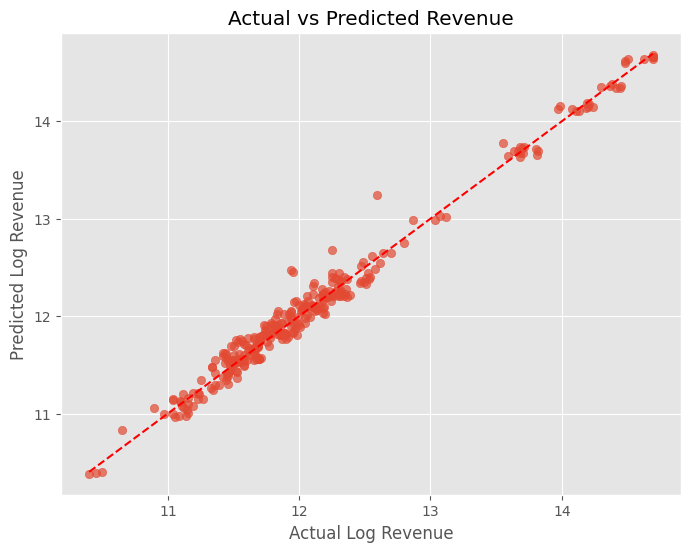

In [41]:
# 13.1 Actual vs Predicted Plot

# Actual vs Predicted Values

plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    rf_pred,
    alpha=0.7
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linestyle='--'
)

plt.xlabel("Actual Log Revenue")
plt.ylabel("Predicted Log Revenue")
plt.title("Actual vs Predicted Revenue")

plt.show()


# Interpretation

# The closer the data points lie to the diagonal reference line, the better the model predicts livestock sales revenue.

In [ ]:
# Comments:
# The x-axis is the Actual Log Revenue, thatis records from livestock sales.
# The y-axis is the Predicted Log Revenue
# The Lod Scales:{11 to 14} are logarithmic transformation. This is used to compress very large numbers. For instance, large poultry sales and goat sales
# The Diagonal Line represents perfect prediction. If the dots are on the line, it means exact prediction.
# When the points below the line it means where the actual log revenue was higher than predicted.
# When the points above the line it means where actual revenue was notably lower than predicted.  
# The points tightly hug the 45-degree line from low revenue values to high revenue values. Which means that model captures
# the overall linear trend and variance in livestock revenue.
# We have outliers which occurred around 12.5  mark on the X-axis. It is for specific livestock that had higher revenue than what was actually earned.

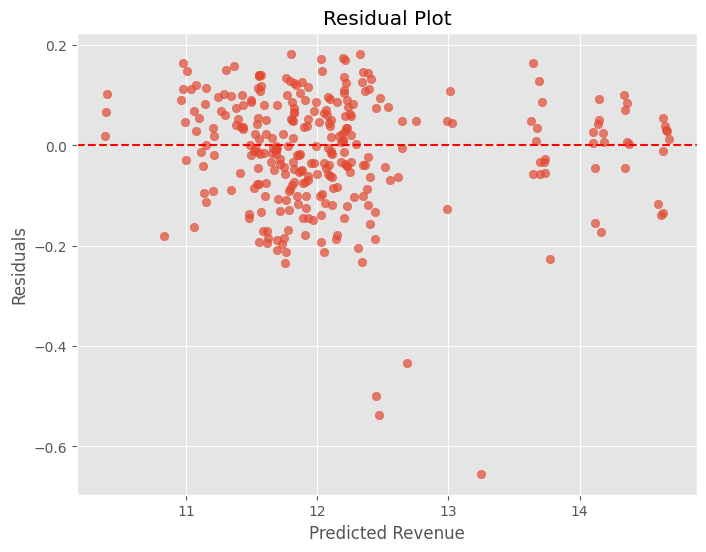

In [ ]:
# 13.2 Residual Plot

# Residual Plot

residuals = y_test - rf_pred

plt.figure(figsize=(8,6))

plt.scatter(
    rf_pred,
    residuals,
    alpha=0.7
)

plt.axhline(
    y=0,
    color='red',
    linestyle='--'
)

plt.xlabel("Predicted Revenue")
plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.show()




In [ ]:
# Interpretation

# Residual = Actual Price - Predicted Price

# This residual plot shows how the livestock revenue predictions missed the actual target.

# X-Axis is the Predicted Revenue on a log scale.
# Y-Axis is the  Residuals that measure prediction errors.
# Zero Line is Perfect prediction baseline where error equals zero.
# Positive Residuals(Underestimated revenue), where actual income beat predictions.
# Negative Residuals(Overestimated revenue), where actual income fell short.

## Farm Insight

# Overall Fit: The randomly scattered dots around zero indicate a healthy model.
# Accuracy: The tight clustering near zero at  12 and 14+ shows excellent large cattle sales forecast.
# Overestimated Outliers: This occurs below -0.4(negative outliers) represent massive prediction failures.
# Risk Zones: This occurs between  12.5 and 13.3, the line is somehow sparingly.

## What Action Should You Take?

# Conduct an Investigate of the Outliers. Also check the historical records for those 4 low dots.
# Identify the factors causing problems. Which could be causalities  as a result of disease outbreaks or high increase in feed.
# Add risk variables to prevent the model from overestimating future high-risk periods.

14. Feature Importance

In [ ]:
# 14.1 Calculate the Feature Importance

# Feature Importance

importance = pd.DataFrame({

    "Feature": X_train.columns,

    "Importance": rf_model.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(20)

,Feature,Importance
7,Livestock_Type_Goat,0.560048
0,Number_Sold,0.317504
8,Livestock_Type_Poultry,0.092471
1,Distance_to_Market_km,0.011540
2,Age,0.008899
5,Month,0.003197
11,Geographic_Zone_South-East,0.002062
4,Vulnerability_Index_Score,0.001271
3,Average_Annual_Rainfall_mm,0.000932
9,Gender_Male,0.000848


In [44]:
print("Number of columns in X:", len(X.columns))
print("Number of feature importances:", len(rf_model.feature_importances_))
print("X_train shape:", X_train.shape)

Number of columns in X: 16
Number of feature importances: 14
X_train shape: (1200, 14)


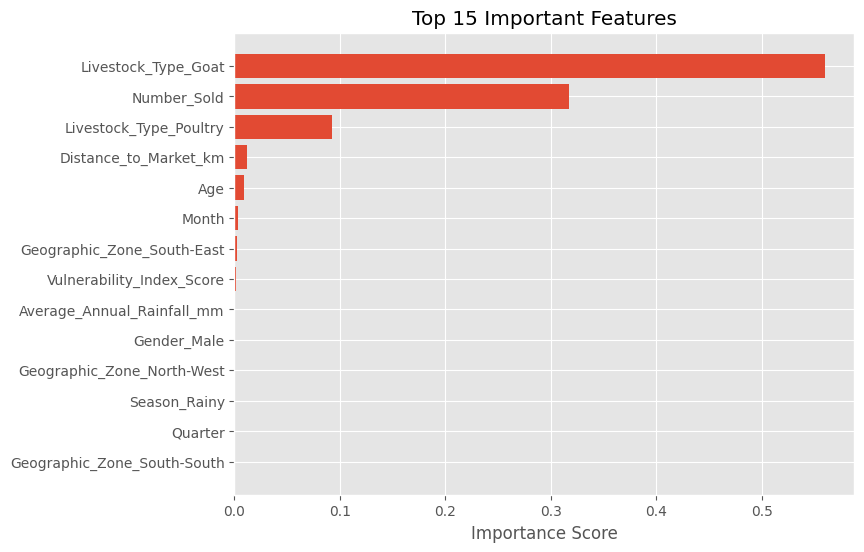

In [45]:
# 14.2 Plot Feature Importance

plt.figure(figsize=(8,6))

top_features = importance.head(15)

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Top 15 Important Features")

plt.xlabel("Importance Score")

plt.show()


# Interpretation

# Features with higher importance scores contribute more strongly to predicting livestock sales revenue.

In [ ]:
# The Random Forest feature importance results show that Livestock_Type_Goat is the most influential 
# predictor of livestock revenue, followed by Number_Sold and Livestock_Type_Poultry. This indicates 
# that livestock type and sales volume are the primary drivers of revenue in the dataset. Other variables 
# such as distance to market, age, month, and geographic zone contribute only marginally to the model’s predictions.

15. Cross-Validation

In [46]:
# Cross-validation evaluates the stability and generalization ability of the model

# Cross Validation

from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(

    rf_model,

    X,

    y,

    cv=5,

    scoring="r2"

)

print("Cross Validation Scores")

print(cv_scores)

print()

print("Average R² Score:", cv_scores.mean())

print("Standard Deviation:", cv_scores.std())


# Interpretation

# A high average R² with a low standard deviation suggests that the model performs consistently across different subsets of the data.

Cross Validation Scores
[0.99995666 0.99992282 0.99995792 0.99986459 0.99994474]

Average R² Score: 0.9999293464709316
Standard Deviation: 3.474276930400195e-05


#### Model Deployment & Inference

16. Save the Trained Model

In [48]:
# Saving the trained model allows it to be reused without retraining.

# Save Model

import joblib

joblib.dump(
    rf_model,
    "livestock_sales_prediction_model.pkl"
)

print("Model saved successfully.")

Model saved successfully.


In [49]:
# Verify Saved Model

import os

os.path.exists("livestock_sales_prediction_model.pkl")

True

17. Load Save Model

In [51]:

# Load Model

loaded_model = joblib.load(
    "livestock_sales_prediction_model.pkl"
)

print("Model loaded successfully.")

Model loaded successfully.


In [52]:
# Verify save Model

loaded_model

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

18 Prediction New Data

In [53]:

# Predict New Observations


sample_prediction = loaded_model.predict(
    X_test.iloc[:10]
)

prediction_df = pd.DataFrame({

    "Actual Revenue": y_test.iloc[:10].values,

    "Predicted Revenue": sample_prediction

})

prediction_df

,Actual Revenue,Predicted Revenue
0,11.747926,11.821299
1,12.137296,12.066671
2,11.596457,11.703868
3,12.079732,11.993178
4,11.504873,11.604775
5,12.466296,12.338952
6,11.681714,11.719605
7,12.148465,12.181136
8,11.687500,11.568262
9,11.236671,11.202217


In [54]:
# Predict Single Observation

single_prediction = loaded_model.predict(
    X_test.iloc[[0]]
)

print("Predicted Log Revenue:", single_prediction[0])

Predicted Log Revenue: 11.821299052882141


In [56]:
# Business Interpretation

print("="*35)
print("Prediction Completed Successfully")
print("="*35)

print("""
The trained Random Forest model successfully predicts
livestock sales revenue based on historical transaction
characteristics.

This demonstrates that the model can support
real-time revenue forecasting and decision-making
within the livestock industry.
""")

Prediction Completed Successfully

The trained Random Forest model successfully predicts
livestock sales revenue based on historical transaction
characteristics.

This demonstrates that the model can support
real-time revenue forecasting and decision-making
within the livestock industry.



#### Reporting & Business Insights

19. Conclusion

In [ ]:
# 19. Conclusion

# I have successfully developed a model that predicts livestock sales revenue using 
# old livestock transaction records. In the development, I followed a structured data analysis industral workflow,which includ data 
# understanding, data cleaning, exploratory data analysis, feature engineering, predictive modelling, model evaluation, and model deployment.

# Three regression regression models were deployed, Linear Regression, Decision Tree Regressor, and Random Forest Regressor.
# They were developed and compared using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and the coefficient of determination (R²).

# During the development and evaluation, the Random Forest Regressor achieved the best predictive performance, demonstrating 
# the ability to capture most of the complex nonlinear relationships within the datasetand also minimize prediction errors. Random Forest Regressor also 
# displayed stability during cross-validation which shows strong capability to capture more data.

# Feature importance analysis  revealed that livestock type, quantity sold, market location, and 
# seasonal characteristics significantly influence livestock business.

# Generally speaking, the developed model provides an effective tool that can forecast livestock business and 
# supports decision within livestock value chain


Summary

In [59]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Predict using the Random Forest model
rf_pred = rf_model.predict(X_test)

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, rf_pred)
rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
r2 = r2_score(y_test, rf_pred)


In [58]:

# Final Model Performance Summary

print("FINAL PROJECT SUMMARY")


print(f"Best Model              : Random Forest Regressor")
print(f"Mean Absolute Error     : {mae:.4f}")
print(f"Root Mean Squared Error : {rmse:.4f}")
print(f"R² Score                : {r2:.4f}")

print("\nModel Status : Successfully Developed")
print("Cross Validation : Completed")
print("Feature Importance : Completed")
print("Prediction : Successful")
print("Deployment : Ready")

FINAL PROJECT SUMMARY
Best Model              : Random Forest Regressor
Mean Absolute Error     : 0.0857
Root Mean Squared Error : 0.1145
R² Score                : 0.9831

Model Status : Successfully Developed
Cross Validation : Completed
Feature Importance : Completed
Prediction : Successful
Deployment : Ready


20. Business Interpretation and Recommendations

In [ ]:
# Business Interpretation and Recommendations

# The developed  machine learning model has practical applications across the livestock industry it's stakeholders

## The Farmers

# The model assist farmers in making estimation on expected sales of livestocks before moving them to market. 
# It also help them in price decision making, plan feeding and make good inventory.

## Livestock Traders

# It help the livestock traders to forecast further revenue, evaluate the best marking time for optimum profit, which redues finacial loss.

## Agricultural Cooperatives

# It help Cooperatives to monitor members' sales performance and advice on how to strategical improve revenue.

## Government Agencies

# It hepls the goverment institutions to identify  performance per regions and evaluate methods to them improve performance. 
# Formulate agricultural policies that will proctect the interest of farmers and livestock traders.
# Make loans or grants avaliable for farmers and livestock traders
# Encourage export of some products for foreign exchange.

## Financial Institutions

# The model will also encourage some financial institutions to make loans avaliable with moderate interest charge if any. This will encourage 
# many to embrace farming and livestock trading as an alternative to sustainable economy



## Recommendations

# The following recommendations are made based on the developed model:

# 1. Increase the collection of farming and livestock business records in order to improve prediction.

# 2. Some the variables that could affect performance such as inflation, price of feed, changing climate condition, 
#    disease outbreaks and demands of products should be included to improve prediction

# 3. In the modeling some advanced model will be including such as XGBoost, LightGBM, CatBoost, and Gradient Boosting Regressor.

